In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
rfm = pd.read_csv("/data/processed/rfm_data.csv")

rfm.head()

,customer_unique_id,last_purchase,recency,frequency,monetary
0,0a0a92112bd4c708ca5fde585afaa872,2017-09-29 15:24:52,383,1,13664.08
1,46450c74a0d8c5ca9395da1daac6c120,2018-08-17 20:06:36,61,3,9553.02
2,da122df9eeddfedc1dc1f5349a1a690c,2017-04-01 15:58:41,564,2,7571.63
3,763c8b1c9c68a0229c42c9fc6f662b93,2018-07-15 14:49:44,94,1,7274.88
4,dc4802a71eae9be1dd28f5d788ceb526,2017-02-12 20:37:36,612,1,6929.31


In [20]:
rfm.info()

rfm.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 96095 entries, 0 to 96094
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  96095 non-null  str    
 1   last_purchase       96095 non-null  str    
 2   recency             96095 non-null  int64  
 3   frequency           96095 non-null  int64  
 4   monetary            96095 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 8.3 MB


customer_unique_id    0
last_purchase         0
recency               0
frequency             0
monetary              0
dtype: int64

In [21]:
rfm["R"] = pd.qcut(
    rfm["recency"],
    5,
    labels=[5,4,3,2,1]
)

In [22]:
rfm["F"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [23]:
rfm["M"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [24]:
rfm["RFM_Score"] = (
    rfm["R"].astype(str) +
    rfm["F"].astype(str) +
    rfm["M"].astype(str)
)

rfm.head()

,customer_unique_id,last_purchase,recency,frequency,monetary,R,F,M,RFM_Score
0,0a0a92112bd4c708ca5fde585afaa872,2017-09-29 15:24:52,383,1,13664.08,2,1,5,215
1,46450c74a0d8c5ca9395da1daac6c120,2018-08-17 20:06:36,61,3,9553.02,5,5,5,555
2,da122df9eeddfedc1dc1f5349a1a690c,2017-04-01 15:58:41,564,2,7571.63,1,5,5,155
3,763c8b1c9c68a0229c42c9fc6f662b93,2018-07-15 14:49:44,94,1,7274.88,5,1,5,515
4,dc4802a71eae9be1dd28f5d788ceb526,2017-02-12 20:37:36,612,1,6929.31,1,1,5,115


In [25]:
def segment(row):

    if row["R"] >= 4 and row["F"] >= 4:
        return "Champions"

    elif row["R"] >= 3 and row["F"] >= 3:
        return "Loyal Customers"

    elif row["R"] >= 4:
        return "Potential Loyalists"

    elif row["R"] <= 2 and row["F"] >= 3:
        return "At Risk"

    else:
        return "Lost Customers"

In [26]:
rfm.columns

Index(['customer_unique_id', 'last_purchase', 'recency', 'frequency',
       'monetary', 'R', 'F', 'M', 'RFM_Score'],
      dtype='str')

In [27]:
rfm.head()

,customer_unique_id,last_purchase,recency,frequency,monetary,R,F,M,RFM_Score
0,0a0a92112bd4c708ca5fde585afaa872,2017-09-29 15:24:52,383,1,13664.08,2,1,5,215
1,46450c74a0d8c5ca9395da1daac6c120,2018-08-17 20:06:36,61,3,9553.02,5,5,5,555
2,da122df9eeddfedc1dc1f5349a1a690c,2017-04-01 15:58:41,564,2,7571.63,1,5,5,155
3,763c8b1c9c68a0229c42c9fc6f662b93,2018-07-15 14:49:44,94,1,7274.88,5,1,5,515
4,dc4802a71eae9be1dd28f5d788ceb526,2017-02-12 20:37:36,612,1,6929.31,1,1,5,115


In [28]:
def segment(row):

    if int(row["R"]) >= 4 and int(row["F"]) >= 4:
        return "Champions"

    elif int(row["R"]) >= 3 and int(row["F"]) >= 3:
        return "Loyal Customers"

    elif int(row["R"]) >= 4:
        return "Potential Loyalists"

    elif int(row["R"]) <= 2 and int(row["F"]) >= 3:
        return "At Risk"

    else:
        return "Lost Customers"

In [29]:
rfm["Segment"] = rfm.apply(segment, axis=1)

In [30]:
rfm[["R", "F", "M", "Segment"]].head()

,R,F,M,Segment
0,2,1,5,Lost Customers
1,5,5,5,Champions
2,1,5,5,At Risk
3,5,1,5,Potential Loyalists
4,1,1,5,Lost Customers


In [31]:
segment_counts = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["Segment", "Customers"]

segment_counts

,Segment,Customers
0,At Risk,23234
1,Lost Customers,22643
2,Loyal Customers,19424
3,Potential Loyalists,15795
4,Champions,14999


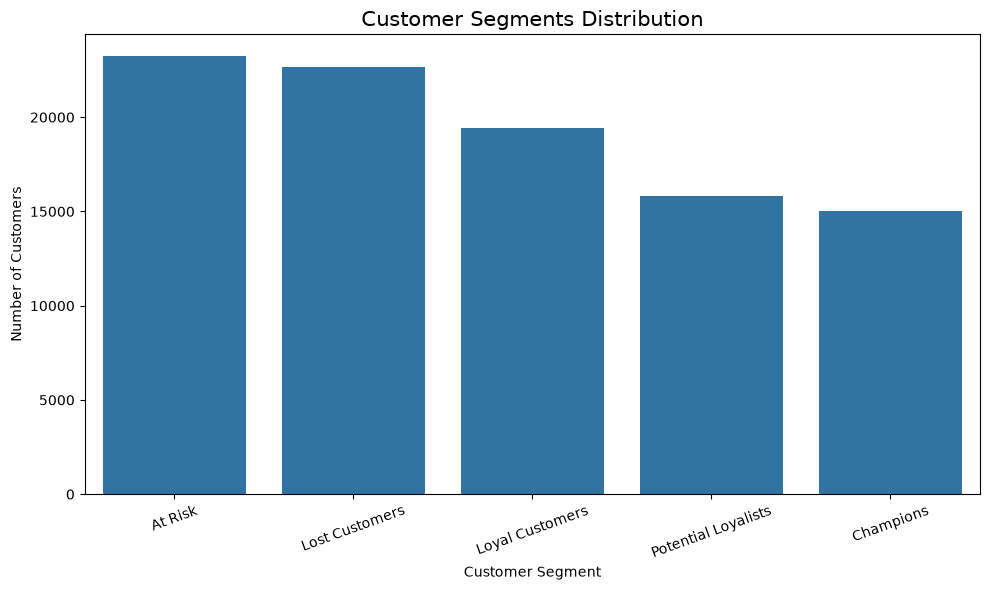

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=segment_counts,
    x="Segment",
    y="Customers"
)

plt.title("Customer Segments Distribution", fontsize=15)
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../images/rfm_segment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
rfm.to_csv(
    "/data/processed/customer_segments.csv",
    index=False
)

## Business Insights

- At Risk customers form the largest customer segment, indicating a significant opportunity for re-engagement campaigns.
- Lost Customers represent a large inactive user base that may require targeted win-back promotions.
- Loyal Customers and Champions together account for a substantial portion of the customer base and should be prioritized through loyalty programs and exclusive offers.
- Potential Loyalists can be nurtured with personalized recommendations and incentives to increase repeat purchases.